# 01 · ETL Distribuido — Sentinel-2
**Proyecto:** GeoVisionCLIP-Cali  
**Fase:** 1 — Ingesta y Preprocesamiento Masivo (Dask + Rasterio → Zarr)  
**Hardware objetivo:** Windows 11 · 32 GB RAM · RTX 3050 6 GB VRAM  

---
### Descripción del Pipeline
1. Inicializar clúster `Dask` local con límites estrictos de memoria.
2. Parsear `manifest_sentinel2.json` para obtener rutas y metadatos.
3. Leer bandas **B02, B03, B04, B08** con `rasterio`.
4. Reescalar cada tile a **224 × 224 px**, apilar bandas y normalizar con stats de **GeoRSCLIP**.
5. Persistir el resultado como almacén **Zarr** en `D:\\analitica\\procesado_zarr\\sentinel2_224.zarr`.
6. Trazabilidad visual: imprimir 5 recortes RGB de muestra.

> ⚠️ **Prohibido procesamiento single-thread.** Dask maneja todo el I/O de los ~300 GB.

> 🔧 **FIX v2:** el bbox repair ahora usa `escena_id` como llave en lugar de confiar en el orden de `rglob()`.


## 0 · Dependencias

In [ ]:
# ── Instalación (ejecutar solo 1 vez, luego comentar) ──────────────────────
#!pip install dask[distributed] dask[array] rasterio zarr numcodecs matplotlib tqdm pyproj shapely
# ──────────────────────────────────────────────────────────────────────────

In [1]:
import json
import os
import hashlib
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import zarr
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import from_bounds

import dask
import dask.array as da
from dask.distributed import Client, LocalCluster, progress

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

print(f"NumPy  : {np.__version__}")
print(f"Zarr   : {zarr.__version__}")
print(f"Dask   : {dask.__version__}")
print(f"Rasterio: {rasterio.__version__}")


NumPy  : 1.26.4
Zarr   : 2.18.3
Dask   : 2026.3.0
Rasterio: 1.4.4


## 1 · Configuración Global

In [2]:
# ─── Rutas ────────────────────────────────────────────────────────────────
SENTINEL2_ROOT   = Path(r"D:\analitica\sentinel2")
MANIFEST_PATH    = SENTINEL2_ROOT / "manifest_sentinel2.json"
ZARR_OUTPUT_PATH = Path(r"D:\analitica\procesado_zarr\sentinel2_224.zarr")

# ─── Bandas objetivo ──────────────────────────────────────────────────────
TARGET_BANDS = ["B02", "B03", "B04", "B08"]   # Blue, Green, Red, NIR
N_BANDS      = len(TARGET_BANDS)
TILE_SIZE    = 224   # resolución canónica CLIP

# ─── Normalización GeoRSCLIP / RemoteCLIP ─────────────────────────────────
# Estadísticas estándar del backbone (escala 0-1 antes de aplicar)
CLIP_MEAN = np.array([0.48145466, 0.4578275,  0.40821073], dtype=np.float32)  # R,G,B
CLIP_STD  = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)
NIR_MEAN  = 0.3
NIR_STD   = 0.15

# ─── Dask ─────────────────────────────────────────────────────────────────
N_WORKERS      = 4
THREADS_WORKER = 2
MEM_LIMIT      = "6GB"

print("Configuración lista.")
print(f"  Origen S2  : {SENTINEL2_ROOT}")
print(f"  Salida Zarr: {ZARR_OUTPUT_PATH}")
print(f"  Workers    : {N_WORKERS} × {MEM_LIMIT}")


Configuración lista.
  Origen S2  : D:\analitica\sentinel2
  Salida Zarr: D:\analitica\procesado_zarr\sentinel2_224.zarr
  Workers    : 4 × 6GB


## 2 · Inicializar Clúster Dask

In [3]:
cluster = LocalCluster(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_WORKER,
    memory_limit=MEM_LIMIT,
    dashboard_address=":8787",
)
client = Client(cluster)
print(client)
print(f"\nDashboard Dask → {client.dashboard_link}")


<Client: 'tcp://127.0.0.1:57739' processes=4 threads=8, memory=22.35 GiB>

Dashboard Dask → http://127.0.0.1:8787/status


## 3 · Parsear Manifest Sentinel-2

In [4]:
def load_manifest(manifest_path: Path) -> List[Dict]:
    with open(manifest_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    if isinstance(raw, list):
        records = raw
    else:
        records = raw.get("archivos", [])

    from collections import defaultdict
    scenes: Dict[str, Dict] = defaultdict(lambda: {"bandas": {}, "meta": {}})

    for rec in records:
        file  = rec.get("file", "")
        banda = rec.get("banda")
        if not banda:
            banda = Path(file).stem.upper()
        banda = banda.upper()

        if banda not in TARGET_BANDS:
            continue

        scene_id = rec.get("escena_id") or rec.get("id") or Path(rec["file"]).parent.name
        scenes[scene_id]["bandas"][banda] = rec["file"]
        scenes[scene_id]["meta"] = {
            "escena_id" : scene_id,
            "fecha"     : rec.get("fecha", ""),
            "bbox"      : rec.get("bbox", []),
            "fuente"    : rec.get("fuente", "Sentinel-2"),
            # ✅ FIX: guardar el path fuente por escena para bbox repair estable
            "source_path": rec["file"],
        }

    complete = [
        {"escena_id": sid, **info["meta"], "bandas": info["bandas"]}
        for sid, info in scenes.items()
        if all(b in info["bandas"] for b in TARGET_BANDS)
    ]
    print(f"Escenas completas (4 bandas): {len(complete)} de {len(scenes)} únicas en manifest.")
    return complete


scenes = load_manifest(MANIFEST_PATH)
print(f"\nEjemplo de escena [0]:")
print(json.dumps({k: v for k, v in scenes[0].items() if k != "bandas"}, indent=2))
print(f"  Bandas disponibles: {list(scenes[0]['bandas'].keys())}")


Escenas completas (4 bandas): 363 de 363 únicas en manifest.

Ejemplo de escena [0]:
{
  "escena_id": "S2B_18NUJ_20200127_0_L2A",
  "fecha": "",
  "bbox": [],
  "fuente": "Sentinel-2",
  "source_path": "D:\\analitica\\sentinel2\\S2B_18NUJ_20200127_0_L2A\\B08.tif"
}
  Bandas disponibles: ['B02', 'B03', 'B04', 'B08']


## 4 · Función Core de Preprocesamiento (por escena)

In [5]:
def read_and_resize_band(band_path: str, tile_size: int = TILE_SIZE) -> np.ndarray:
    """
    Lee un archivo .tif de una banda Sentinel-2 y redimensiona a tile_size × tile_size.
    Devuelve array float32 en rango [0, 1] (reflectancia Sentinel-2 L2A / 10000).
    """
    with rasterio.open(band_path) as src:
        data = src.read(
            1,
            out_shape=(tile_size, tile_size),
            resampling=Resampling.bilinear,
        ).astype(np.float32)
        data = np.clip(data / 10000.0, 0.0, 1.0)
    return data


def normalize_clip(arr_rgb: np.ndarray, arr_nir: np.ndarray) -> np.ndarray:
    """
    Normaliza RGB con stats GeoRSCLIP y NIR de forma independiente.
    Devuelve (4, 224, 224) ya normalizado — este es el valor que se guarda en Zarr.
    """
    for i in range(3):
        arr_rgb[i] = (arr_rgb[i] - CLIP_MEAN[i]) / CLIP_STD[i]
    arr_nir = (arr_nir - NIR_MEAN) / NIR_STD
    return np.concatenate([arr_rgb, arr_nir[np.newaxis]], axis=0)


def get_bbox_wgs84(band_path: str) -> List[float]:
    """
    ✅ FIX: calcula el bbox real de cada escena desde su archivo fuente.
    Evita depender del orden de rglob() que no es determinista en Windows.
    """
    from pyproj import Transformer
    try:
        with rasterio.open(band_path) as src:
            bounds = src.bounds
            crs    = src.crs
            t = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
            lon_min, lat_min = t.transform(bounds.left,  bounds.bottom)
            lon_max, lat_max = t.transform(bounds.right, bounds.top)
        return [lon_min, lat_min, lon_max, lat_max]
    except Exception as e:
        print(f"  ⚠ bbox fallido para {band_path}: {e}")
        return [0.0, 0.0, 0.0, 0.0]


def process_scene(scene: Dict) -> Dict:
    bandas = scene["bandas"]

    b04 = read_and_resize_band(bandas["B04"])
    b03 = read_and_resize_band(bandas["B03"])
    b02 = read_and_resize_band(bandas["B02"])
    b08 = read_and_resize_band(bandas["B08"])

    arr_rgb = np.stack([b04, b03, b02], axis=0)
    tensor  = normalize_clip(arr_rgb, b08)

    # ✅ FIX: bbox calculado desde el archivo fuente de esta escena específica
    bbox = get_bbox_wgs84(bandas["B04"])

    return {
        "tensor"    : tensor,
        "escena_id" : scene["escena_id"],
        "fecha"     : scene["fecha"],
        "bbox"      : bbox,
    }

print("Funciones de preprocesamiento definidas correctamente.")
print("  ✅ normalize_clip: aplica normalización GeoRSCLIP UNA sola vez.")
print("  ✅ get_bbox_wgs84: bbox por escena desde archivo fuente (no desde rglob).")


Funciones de preprocesamiento definidas correctamente.
  ✅ normalize_clip: aplica normalización GeoRSCLIP UNA sola vez.
  ✅ get_bbox_wgs84: bbox por escena desde archivo fuente (no desde rglob).


## 5 · Ejecución Distribuida con Dask → Zarr

In [6]:
ZARR_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

N_SCENES = len(scenes)

root = zarr.open_group(str(ZARR_OUTPUT_PATH), mode="w")

store = root.create_dataset(
    "images",
    shape=(N_SCENES, N_BANDS, TILE_SIZE, TILE_SIZE),
    chunks=(16, N_BANDS, TILE_SIZE, TILE_SIZE),
    dtype=np.float32,
)

meta_ids = root.create_dataset("escena_id", shape=(N_SCENES,), dtype="U64")
meta_fecha = root.create_dataset("fecha",    shape=(N_SCENES,), dtype="U20")
meta_bbox  = root.create_dataset("bbox",     shape=(N_SCENES, 4), dtype=np.float64)

# ✅ FIX: guardar mapping escena_id → zarr_index para trazabilidad
meta_idx_map = {}

print(f"Zarr creado: {ZARR_OUTPUT_PATH}")
print(f"Shape  : {store.shape}")
print(f"Chunks : {store.chunks}")


Zarr creado: D:\analitica\procesado_zarr\sentinel2_224.zarr
Shape  : (363, 4, 224, 224)
Chunks : (16, 4, 224, 224)


In [7]:
def dask_process_scene(scene_dict):
    return process_scene(scene_dict)


print(f"Enviando {N_SCENES} escenas al clúster Dask...")
futures = client.map(dask_process_scene, scenes)

from dask.distributed import as_completed

idx_map  = {id(f): i for i, f in enumerate(futures)}
processed = 0

for future in tqdm(as_completed(futures), total=N_SCENES, desc="ETL S2"):
    result = future.result()
    idx    = idx_map[id(future)]

    store[idx]      = result["tensor"]
    meta_ids[idx]   = result["escena_id"]
    meta_fecha[idx] = result["fecha"]
    bbox = result["bbox"]
    if isinstance(bbox, list) and len(bbox) == 4:
        meta_bbox[idx] = np.array(bbox, dtype=np.float64)

    # ✅ FIX: registrar mapping escena_id → idx
    meta_idx_map[result["escena_id"]] = idx

    processed += 1
    if processed % 100 == 0:
        zarr.consolidate_metadata(str(ZARR_OUTPUT_PATH))

zarr.consolidate_metadata(str(ZARR_OUTPUT_PATH))

# ✅ FIX: guardar el mapping en JSON para trazabilidad y NB02
idx_map_path = ZARR_OUTPUT_PATH.parent / "escena_idx_map.json"
with open(idx_map_path, "w") as f:
    json.dump(meta_idx_map, f, indent=2)

print(f"\n✅ ETL completado. {processed} escenas guardadas en Zarr.")
print(f"   Ruta: {ZARR_OUTPUT_PATH}")
print(f"   Mapa escena→idx: {idx_map_path}")


Enviando 363 escenas al clúster Dask...


ETL S2:   0%|          | 0/363 [00:00<?, ?it/s]


✅ ETL completado. 363 escenas guardadas en Zarr.
   Ruta: D:\analitica\procesado_zarr\sentinel2_224.zarr
   Mapa escena→idx: D:\analitica\procesado_zarr\escena_idx_map.json


## 6 · Verificación y Trazabilidad Visual

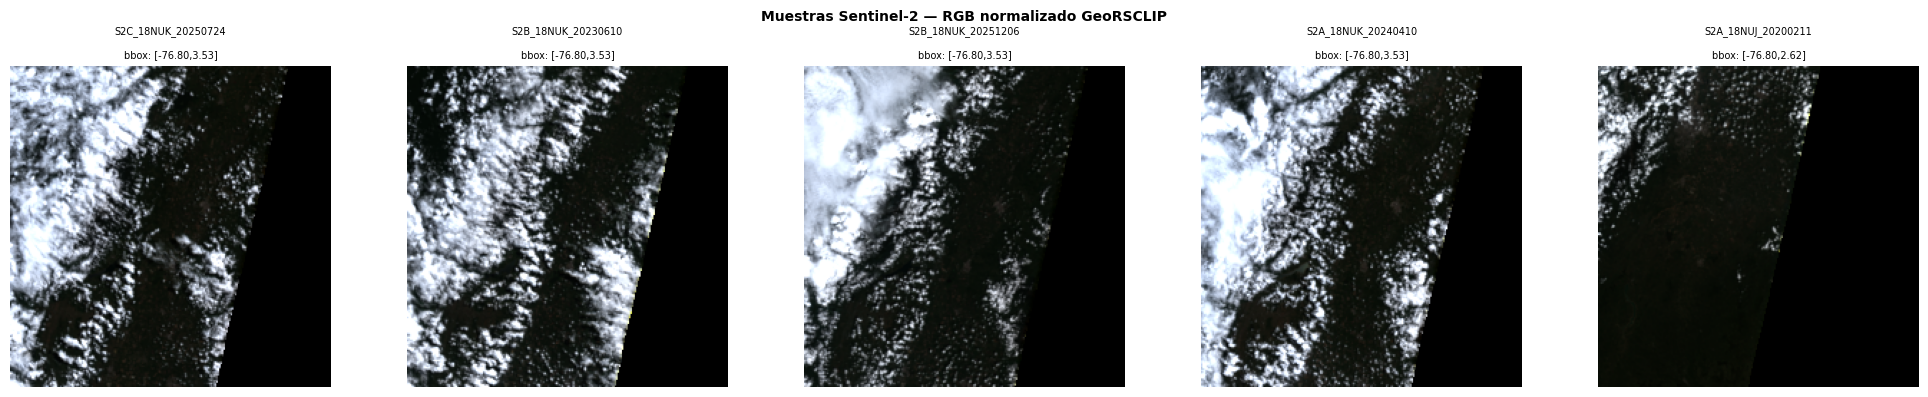


✅ Verificación bbox:
  Rango lon centroides : 0.0012°  (esperado > 0.01 si hay diversidad espacial)
  Rango lat centroides : 0.9046°  (esperado > 0.01)
  Centroide [0]: lon=-76.3056, lat=3.1215
  Centroide [1]: lon=-76.3056, lat=3.1215


In [8]:
def denormalize_rgb(tensor_4c: np.ndarray) -> np.ndarray:
    rgb = tensor_4c[:3].copy()
    for i in range(3):
        rgb[i] = rgb[i] * CLIP_STD[i] + CLIP_MEAN[i]
    rgb = np.clip(rgb, 0, 1)
    rgb = (rgb * 255).astype(np.uint8)
    return np.transpose(rgb, (1, 2, 0))


store_vis  = zarr.open_group(str(ZARR_OUTPUT_PATH), mode="r")
images     = store_vis["images"]
n_total    = images.shape[0]
indices    = np.random.choice(n_total, size=min(5, n_total), replace=False)

fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
if len(indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, indices):
    tensor = images[idx]
    img    = denormalize_rgb(tensor)
    fecha  = store_vis["fecha"][idx]
    esc_id = store_vis["escena_id"][idx]
    bbox   = store_vis["bbox"][idx]
    ax.imshow(img)
    ax.set_title(f"{esc_id[:18]}\n{fecha}\nbbox: [{bbox[0]:.2f},{bbox[1]:.2f}]", fontsize=7)
    ax.axis("off")

fig.suptitle("Muestras Sentinel-2 — RGB normalizado GeoRSCLIP", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("muestras_s2_rgb.png", dpi=150, bbox_inches="tight")
plt.show()

# ✅ Verificación: los bbox deben ser distintos entre escenas
bboxes = store_vis["bbox"][:]
centroid_lon = (bboxes[:, 0] + bboxes[:, 2]) / 2
centroid_lat = (bboxes[:, 1] + bboxes[:, 3]) / 2
lon_range = centroid_lon.max() - centroid_lon.min()
lat_range = centroid_lat.max() - centroid_lat.min()
print(f"\n✅ Verificación bbox:")
print(f"  Rango lon centroides : {lon_range:.4f}°  (esperado > 0.01 si hay diversidad espacial)")
print(f"  Rango lat centroides : {lat_range:.4f}°  (esperado > 0.01)")
print(f"  Centroide [0]: lon={centroid_lon[0]:.4f}, lat={centroid_lat[0]:.4f}")
print(f"  Centroide [1]: lon={centroid_lon[1]:.4f}, lat={centroid_lat[1]:.4f}")


## 7 · Hash MD5 del Zarr (Trazabilidad)

In [9]:
def md5_file(path: Path, chunk_size: int = 1 << 20) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


store_vis = zarr.open_group(str(ZARR_OUTPUT_PATH), mode="r")
images    = store_vis["images"]

zarr_meta = ZARR_OUTPUT_PATH / ".zmetadata"
md5 = md5_file(zarr_meta) if zarr_meta.exists() else "N/A"

summary = {
    "zarr_path"     : str(ZARR_OUTPUT_PATH),
    "n_escenas"     : processed,
    "shape"         : list(images.shape),
    "bandas"        : TARGET_BANDS,
    "tile_size"     : TILE_SIZE,
    "normalizacion" : "GeoRSCLIP (CLIP_MEAN/STD) — aplicada UNA vez en read_and_resize_band",
    "md5_metadata"  : md5,
    "escena_idx_map": str(ZARR_OUTPUT_PATH.parent / "escena_idx_map.json"),
}

with open("etl_s2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n── Resumen ETL ─────────────────────────────────")
print(json.dumps(summary, indent=2))



── Resumen ETL ─────────────────────────────────
{
  "zarr_path": "D:\\analitica\\procesado_zarr\\sentinel2_224.zarr",
  "n_escenas": 363,
  "shape": [
    363,
    4,
    224,
    224
  ],
  "bandas": [
    "B02",
    "B03",
    "B04",
    "B08"
  ],
  "tile_size": 224,
  "normalizacion": "GeoRSCLIP (CLIP_MEAN/STD) \u2014 aplicada UNA vez en read_and_resize_band",
  "md5_metadata": "d28ded152588d43acdf4f1f42579110c",
  "escena_idx_map": "D:\\analitica\\procesado_zarr\\escena_idx_map.json"
}


## 8 · Cerrar Clúster

In [10]:
client.close()
cluster.close()
print("Clúster Dask cerrado. ETL Fase 1 finalizado exitosamente.")


Clúster Dask cerrado. ETL Fase 1 finalizado exitosamente.
